In [1]:
import os

# Safely list files under ./input (single quick pass)
print('\n'.join([
    os.path.join(root, f)
    for root, _, files in os.walk('./input')
    for f in files
]))

import numpy as np
import pandas as pd

./input/titanic.zip
./input/gender_submission.csv
./input/test.csv
./input/train.csv
./input/titanic.zip:Zone.Identifier


In [2]:
train =pd.read_csv('./input/train.csv')
test = pd.read_csv('./input/test.csv')
gender_submission = pd.read_csv('./input/gender_submission.csv')

In [3]:
data = pd.concat([train,test],sort = False)
data['Sex']=data['Sex'].replace(['male','female'],[0,1])
#male,femaleを０１に変換

/tmp/ipykernel_936/3092714075.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Sex']=data['Sex'].replace(['male','female'],[0,1])


In [4]:
data['Fare']=data['Fare'].fillna(np.mean(data['Fare']))
data['Embarked']= data['Embarked'].fillna('S').map({'S':0,'C':1,'Q':2}).astype(int)
age_ave = data['Age'].mean()
age_std = data['Age'].std()
data['Age'] = data['Age'].fillna(np.random.randint(age_ave - age_std,age_ave+ age_std))
#np.ranom.randint(a,b)はa以上b未満の整数をランダム生成
#data[].fillna(implace=True)みたいにやるのは古いのでdata[] = data[].fillnaにする

In [5]:
delete_columns = ['Name', 'PassengerId', 'Parch', 'Ticket', 'Cabin']
data = data.drop(delete_columns, axis=1)
#いらない特徴量を消す

In [6]:
train = data[:len(train)]
test = data[len(train):]
#行数で分離

In [7]:
y_train = train['Survived']
X_train = train.drop('Survived', axis=1)
X_test = test.drop('Survived', axis=1)
#最終結果だけ分離

In [8]:
categorical_features = ['Embarked', 'Pclass', 'Sex']
#カテゴリ変数だと宣言しないと連続数とみなされる。

In [9]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
#stratifiedKFold:y==1の比率をy_trainと一致させるように分割する

y_preds = []
models = []
oof_train = np.zeros((len(X_train),))
# out-of-fold予測値を入れる配列

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
#KFoldで交差検証の分割を定義,5回trainとvalidに分割、データをシャッフル、乱数シード0で固定
categorical_features = ['Embarked', 'Pclass', 'Sex']

params = {
    'objective': 'binary',
    'max_bin': 300,
    'learning_rate': 0.05,
    'num_leaves': 40
}
#ここからfor分で回す
#X_trainをtrain_indexとvalid_indexに分割、これらは行番号しか返さない
#fold_idは0から始まる分割の番号
for fold_id, (train_index, valid_index) in enumerate(cv.split(X_train, y_train)):
    #行番号の範囲を指定してデータを取り出す
    X_tr = X_train.loc[train_index, :]
    X_val = X_train.loc[valid_index, :]
    #こっちは解答を分割
    y_tr = y_train[train_index]
    y_val = y_train[valid_index]
 #LightGBMのデータセットを作成
    lgb_train = lgb.Dataset(X_tr, y_tr,
                                             categorical_feature=categorical_features)
    lgb_eval = lgb.Dataset(X_val, y_val, reference=lgb_train,
                                            categorical_feature=categorical_features)

    model = lgb.train(params, lgb_train,
                                   valid_sets=[lgb_train, lgb_eval],
                                   callbacks=[lgb.log_evaluation(10), lgb.early_stopping(10)],
                                   num_boost_round=1000)

#out-of-fold:valid側のデータに対する予測値を入れる
    oof_train[valid_index] = model.predict(X_val, num_iteration=model.best_iteration)
#テストデータ全体のX_testに対する予測値を保存  
    y_pred = model.predict(X_test, num_iteration=model.best_iteration)
#五回分がどんどんリストに順番に追加していく
    y_preds.append(y_pred)
    models.append(model)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002931 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 194
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

In [10]:
#分割したvalid側のデータに対する予測値csvにする。index=Falseでインデックス列を消す
pd.DataFrame(oof_train).to_csv('oof_train_kfold.csv', index=False)

#.trainするとかってにlgb_train.lgb_evalはtraining,valid_1になる
#binaly指定だとbinary_loglossがデフォルト評価指標
#valid_1の中のbinary_loglossを取り出してリストに格納
#modelsは5個のモデルが入っている、その中のそれぞれのbest_scoreを取り出す
#内包表記で一気にリスト化
scores = [
    m.best_score['valid_1']['binary_logloss'] for m in models
]
#平均スコアを計算
score = sum(scores) / len(scores)
print('===CV scores===')
print(scores)
print(score)

===CV scores===
[np.float64(0.37142718694361315), np.float64(0.38164001617510607), np.float64(0.4064767969509267), np.float64(0.4325066780179788), np.float64(0.4875298790718805)]
0.41591611143190105


In [11]:
from sklearn.metrics import accuracy_score

#oof_trainの中の確率を０１に変換.整数
#oof_trainって五回繰り返したデータだけど
# valid_indexの分割の仕方がかぶってないからうまいこと五回分で全体の予測データができている
y_pred_oof = (oof_train > 0.5).astype(int)
#この正解率は五回の寄せ集めの正解率なのでy_predの予測値のようにアンサンブルしていないため性能は低くでる
accuracy_score(y_train, y_pred_oof)

0.8316498316498316

In [12]:
y_pred = (y_pred > 0.5).astype(int)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

In [13]:
len(y_preds)

5

In [14]:
y_preds[0][:10]

array([0.0661865 , 0.43938058, 0.09869395, 0.20822645, 0.50408602,
       0.30343588, 0.65794934, 0.15386117, 0.66564683, 0.05342908])

In [15]:
#y_predsは5回分のもともとのテストデータに対する予測値が入っているリスト,y_subはその平均値
y_sub = sum(y_preds) / len(y_preds)
y_sub = (y_sub > 0.5).astype(int)
y_sub[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

In [ ]:
sub = pd.read_csv('./input/gender_submission.csv')
sub['Survived'] = y_sub
sub.to_csv('submission_lightgbm_kfold.csv', index=False)

sub.head()
#kaglleのスコアは0.77751

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

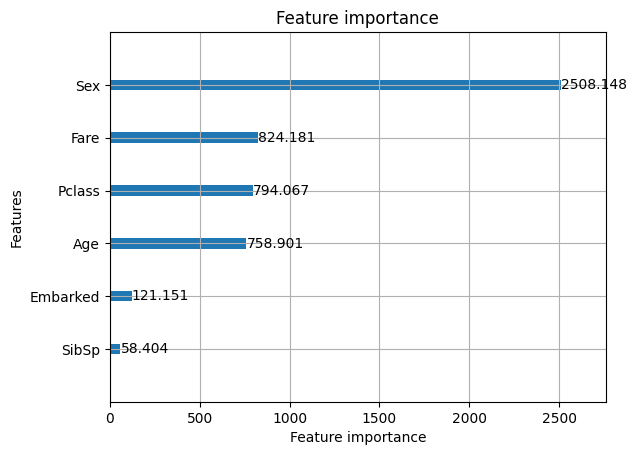

In [17]:
lgb.plot_importance(model, importance_type='gain')